In [15]:
# Data Cleaning
# EDA


In [5]:
import os
import zipfile
import pandas as pd
import re
import time
import pyarrow as pa


# Set the path to your root folder containing all the historical_data_XXXX folders
BASE_DIR = r'D:\AI'
OUTPUT_DIR = r'D:\AI'  # <-- CHANGE THIS to a drive with space!

orig_header_path = r'D:\AI\origination_data_file_header.txt'
perf_header_path = r'D:\AI\performance_data_file_header.txt'

# Ensure the output folder exists
os.makedirs(OUTPUT_DIR, exist_ok=True)


# Create dedicated folders for the two datasets
orig_output_dir = os.path.join(OUTPUT_DIR, 'master_orig_dataset')
perf_output_dir = os.path.join(OUTPUT_DIR, 'master_perf_dataset')
os.makedirs(orig_output_dir, exist_ok=True)
os.makedirs(perf_output_dir, exist_ok=True)

# --- 2. LOAD HEADERS ---
print("Loading headers...")
orig_columns = pd.read_csv(orig_header_path, sep="|", header=0, nrows=1).columns.tolist()
perf_columns = pd.read_csv(perf_header_path, sep="|", header=0, nrows=1).columns.tolist()

print("Starting processing. This will compress the data significantly.\n")
start_time = time.time()
files_processed = 0


# --- 3. PROCESS AND SAVE AS PARTITIONED PARQUET ---
for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        if file.endswith('.zip'):
            zip_path = os.path.join(root, file)
            print(f"Processing: {file}")
            
            with zipfile.ZipFile(zip_path, 'r') as z:
                orig_files = [f for f in z.namelist() if os.path.basename(f).startswith('orig_') and f.endswith('.txt')]
                perf_files = [f for f in z.namelist() if os.path.basename(f).startswith('perf_') and f.endswith('.txt')]
                
                # --- PROCESS ORIG ---
                if orig_files:
                    orig_file = orig_files[0]
                    quarter_match = re.search(r'(\d{4}Q\d)', orig_file)
                    quarter = quarter_match.group(1) if quarter_match else 'Unknown'
                    
                    # FIX: Removed index_col=False to satisfy the pyarrow engine
                    df_quarter = pd.read_csv(z.open(orig_file), sep="|", header=None, engine='pyarrow')
                    df_quarter.columns = orig_columns
                    df_quarter['quarter'] = quarter
                    
                    # Save directly to compressed parquet
                    parquet_path = os.path.join(orig_output_dir, f'orig_{quarter}.parquet')
                    df_quarter.to_parquet(parquet_path, compression='zstd', index=False)
                        
                # --- PROCESS PERF ---
                if perf_files:
                    perf_file = perf_files[0]
                    quarter_match = re.search(r'(\d{4}Q\d)', perf_file)
                    quarter = quarter_match.group(1) if quarter_match else 'Unknown'
                    
                    # FIX: Removed index_col=False to satisfy the pyarrow engine
                    df_quarter = pd.read_csv(z.open(perf_file), sep="|", header=None, engine='pyarrow')
                    df_quarter.columns = perf_columns
                    df_quarter['quarter'] = quarter
                    
                    parquet_path = os.path.join(perf_output_dir, f'perf_{quarter}.parquet')
                    df_quarter.to_parquet(parquet_path, compression='zstd', index=False)
            
            files_processed += 1

# --- 4. WRAP UP ---
end_time = time.time()
total_minutes = round((end_time - start_time) / 60, 2)

print(f"\n🎉 SUCCESS!")
print(f"Processed {files_processed} zip files in {total_minutes} minutes.")
print(f"Orig data saved to: {orig_output_dir}")
print(f"Perf data saved to: {perf_output_dir}")


Loading headers...
Starting processing. This will compress the data significantly.

Processing: historical_data_1999Q1.zip
Processing: historical_data_1999Q2.zip
Processing: historical_data_1999Q3.zip
Processing: historical_data_1999Q4.zip
Processing: historical_data_2000Q1.zip
Processing: historical_data_2000Q2.zip
Processing: historical_data_2000Q3.zip
Processing: historical_data_2000Q4.zip
Processing: historical_data_2001Q1.zip
Processing: historical_data_2001Q2.zip
Processing: historical_data_2001Q3.zip
Processing: historical_data_2001Q4.zip
Processing: historical_data_2002Q1.zip
Processing: historical_data_2002Q2.zip
Processing: historical_data_2002Q3.zip
Processing: historical_data_2002Q4.zip
Processing: historical_data_2003Q1.zip
Processing: historical_data_2003Q2.zip
Processing: historical_data_2003Q3.zip
Processing: historical_data_2003Q4.zip
Processing: historical_data_2004Q1.zip
Processing: historical_data_2004Q2.zip
Processing: historical_data_2004Q3.zip
Processing: histori

Querying data with DuckDB... (This may take 1-3 minutes)
Successfully aggregated 47,274,026 loans into memory.

Unique Occupancy Statuses found:
OCCUPANCY_STATUS
P    44529681
I     2744345
Name: count, dtype: int64

Primary Residence (P) loans: 44,529,681 | Investment (I) loans: 2,744,345

--- Log-Rank Test Results ---
Test Statistic: 40.60
P-Value: 1.87e-10


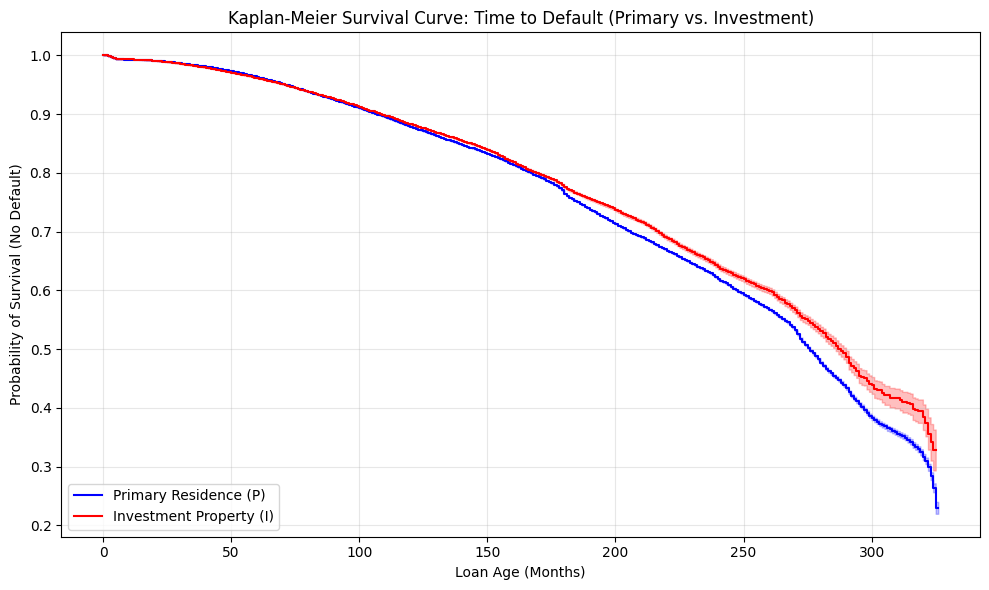

In [9]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# --- 1. SET YOUR PATHS ---
# Point these to the folders where you saved your Parquet files
ORIG_PARQUET_PATH = r'D:\AI\master_orig_dataset'
PERF_PARQUET_PATH = r'D:\AI\master_perf_dataset'

print("Querying data with DuckDB... (This may take 1-3 minutes)")

# --- 2. ROBUST DUCKDB QUERY ---
# Notice: We now SELECT "OCCUPANCY STATUS" instead of "AMORTIZATION TYPE"
query = f"""
    WITH loan_outcomes AS (
        SELECT 
            "LOAN IDENTIFIER",
            CAST(MAX("LOAN AGE") AS INTEGER) AS final_age,
            CAST(MAX(CASE 
                WHEN "CURRENT LOAN DELINQUENCY STATUS" >= '03' THEN 1 
                WHEN "ZERO BALANCE CODE" IN ('03', '09') THEN 1 
                ELSE 0 
            END) AS INTEGER) AS event
        FROM read_parquet('{PERF_PARQUET_PATH}')
        GROUP BY "LOAN IDENTIFIER"
    )
    SELECT 
        TRIM(o."OCCUPANCY STATUS") AS OCCUPANCY_STATUS,
        lo.final_age,
        lo.event
    FROM loan_outcomes lo
    JOIN read_parquet('{ORIG_PARQUET_PATH}') o 
      ON lo."LOAN IDENTIFIER" = o."LOAN IDENTIFIER"
    WHERE TRIM(o."OCCUPANCY STATUS") IN ('P', 'I')
"""

df = duckdb.query(query).df()

print(f"Successfully aggregated {len(df):,} loans into memory.")
print("\nUnique Occupancy Statuses found:")
print(df["OCCUPANCY_STATUS"].value_counts())

# --- 3. DATA CLEANING (Crucial for lifelines) ---
# Drop any rows where age or event is missing
df = df.dropna(subset=['final_age', 'event'])

# Force numeric types to guarantee lifelines accepts them
df['final_age'] = df['final_age'].astype(int)
df['event'] = df['event'].astype(int)

# --- 4. SURVIVAL ANALYSIS WITH LIFELINES ---
plt.figure(figsize=(10, 6))

# Filter data for each group (Using the correct column name from SQL)
df_primary = df[df["OCCUPANCY_STATUS"] == "P"]
df_investment = df[df["OCCUPANCY_STATUS"] == "I"]

print(f"\nPrimary Residence (P) loans: {len(df_primary):,} | Investment (I) loans: {len(df_investment):,}")

# Initialize Kaplan-Meier fitters
kmf_primary = KaplanMeierFitter()
kmf_investment = KaplanMeierFitter()

# Fit Primary (Should always exist)
kmf_primary.fit(df_primary["final_age"], event_observed=df_primary["event"], label="Primary Residence (P)")
ax = kmf_primary.plot(ci_show=True, color="blue")

# Fit Investment (Only if we actually have Investment loans)
if len(df_investment) > 0:
    kmf_investment.fit(df_investment["final_age"], event_observed=df_investment["event"], label="Investment Property (I)")
    kmf_investment.plot(ax=ax, ci_show=True, color="red")
    
    # Statistical Significance (Log-Rank Test)
    results = logrank_test(
        df_primary["final_age"], df_investment["final_age"], 
        event_observed_A=df_primary["event"], event_observed_B=df_investment["event"]
    )
    print("\n--- Log-Rank Test Results ---")
    print(f"Test Statistic: {results.test_statistic:.2f}")
    print(f"P-Value: {results.p_value:.2e}")
else:
    print("\n⚠️ WARNING: No Investment loans found in this dataset. Plotting Primary only.")

# Formatting the plot
plt.title("Kaplan-Meier Survival Curve: Time to Default (Primary vs. Investment)")
plt.xlabel("Loan Age (Months)")
plt.ylabel("Probability of Survival (No Default)")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
import duckdb
import pandas as pd
import numpy as np
import os
import time

# --- 1. SET YOUR PATHS ---
ORIG_PARQUET_PATH = r'D:\AI\master_orig_dataset\*.parquet'
PERF_PARQUET_PATH = r'D:\AI\master_perf_dataset\*.parquet'
OUTPUT_PATH = r'D:\AI\dtsa_sample.parquet'

print("Starting Phase 1: Data Extraction and Sampling...")
start_time = time.time()

# --- 2. DUCKDB QUERY ---
# We use a CTE to first grab a 5% random sample of Loan Identifiers.
# Then we join ONLY those loans' performance and origination data.
query = f"""
    WITH sampled_loans AS (
        SELECT "LOAN IDENTIFIER"
        FROM read_parquet('{ORIG_PARQUET_PATH}')
        USING SAMPLE 5 PERCENT
    )
    SELECT 
        p."LOAN IDENTIFIER",
        p."PERIOD",
        p."LOAN AGE",
        
        -- STATIC COVARIATES (From Origination)
        o."CLASSIC FICO",
        o."ORIGINAL LOAN-TO-VALUE (LTV)",
        o."OCCUPANCY STATUS",
        o."CHANNEL",
        o."AMORTIZATION TYPE",
        o."ORIGINAL LOAN TERM",
        o."ORIGINAL UPB",
        
        -- TIME-VARYING COVARIATES (From Performance)
        p."ESTIMATED LOAN-TO-VALUE (ELTV)",
        p."CURRENT ACTUAL UPB",
        p."CURRENT INTEREST RATE",
        p."MODIFICATION FLAG",
        
        -- EVENT INDICATORS (Needed for censoring and target creation)
        p."CURRENT LOAN DELINQUENCY STATUS",
        p."ZERO BALANCE CODE",
        
        -- TARGET VARIABLE: 1 if default THIS month, 0 otherwise
        CASE 
            WHEN p."CURRENT LOAN DELINQUENCY STATUS" >= '03' THEN 1
            WHEN p."ZERO BALANCE CODE" IN ('03', '09') THEN 1
            ELSE 0 
        END AS default_event

    FROM read_parquet('{PERF_PARQUET_PATH}') p
    INNER JOIN sampled_loans s 
        ON p."LOAN IDENTIFIER" = s."LOAN IDENTIFIER"
    INNER JOIN read_parquet('{ORIG_PARQUET_PATH}') o 
        ON p."LOAN IDENTIFIER" = o."LOAN IDENTIFIER"
"""

print("Executing DuckDB query (this may take 2-5 minutes depending on disk speed)...")
df = duckdb.query(query).df()
print(f"✅ Successfully extracted {len(df):,} loan-month records into memory.")

# --- 3. DATA CENSORING (CRITICAL FOR SURVIVAL ANALYSIS) ---
print("Applying survival analysis censoring rules...")

# Sort by loan and time to ensure chronological order
df = df.sort_values(['LOAN IDENTIFIER', 'PERIOD']).reset_index(drop=True)

# A loan is "terminated" if it defaults OR if it has ANY zero balance code (e.g., prepaid '01')
# We only want to keep rows UP TO AND INCLUDING the month of termination.
df['is_terminated'] = (df['default_event'] == 1) | (df['ZERO BALANCE CODE'].notna())

# Shift the termination flag by 1 month per loan. 
# If a loan terminated in the *previous* month, we drop the current month.
df['terminated_prev_month'] = df.groupby('LOAN IDENTIFIER')['is_terminated'].shift(1).fillna(False)

# Keep only rows where the loan did NOT terminate in the previous month
df_censored = df[df['terminated_prev_month'] == False].copy()

print(f"✅ Censoring applied. Reduced from {len(df):,} to {len(df_censored):,} loan-month records.")

# --- 4. MINOR CLEANING (Handling Freddie Mac 'Not Available' codes) ---
print("Cleaning Freddie Mac 'Not Available' codes (999, 9999)...")

# Replace Freddie Mac's 'Not Available' placeholders with actual NaNs
# Based on the data dictionary: 999 or 9999 means Not Available
cols_to_clean = ['CLASSIC FICO', 'ORIGINAL LOAN-TO-VALUE (LTV)', 'ORIGINAL LOAN TERM', 'ESTIMATED LOAN-TO-VALUE (ELTV)']
for col in cols_to_clean:
    if col in df_censored.columns:
        df_censored[col] = df_censored[col].replace(['999', '9999', 999, 9999], np.nan)

# Drop the helper columns we no longer need
df_censored = df_censored.drop(columns=['CURRENT LOAN DELINQUENCY STATUS', 'ZERO BALANCE CODE', 'is_terminated', 'terminated_prev_month'])

# --- 5. SAVE TO PARQUET ---
print(f"Saving final dataset to {OUTPUT_PATH}...")
df_censored.to_parquet(OUTPUT_PATH, compression='zstd', index=False)

end_time = time.time()
total_minutes = round((end_time - start_time) / 60, 2)

print(f"\n🎉 PHASE 1 COMPLETE!")
print(f"Total time: {total_minutes} minutes")
print(f"Final dataset shape: {df_censored.shape[0]:,} rows × {df_censored.shape[1]} columns")
print(f"Saved to: {OUTPUT_PATH}")

# Quick sanity check of the target variable
print("\n--- Target Variable Summary ---")
print(df_censored['default_event'].value_counts(normalize=True).map('{:.2%}'.format))

Starting Phase 1: Data Extraction and Sampling...
Executing DuckDB query (this may take 2-5 minutes depending on disk speed)...
✅ Successfully extracted 143,196,926 loan-month records into memory.
Applying survival analysis censoring rules...


C:\Users\josep\AppData\Local\Temp\ipykernel_13380\3312274808.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['terminated_prev_month'] = df.groupby('LOAN IDENTIFIER')['is_terminated'].shift(1).fillna(False)


✅ Censoring applied. Reduced from 143,196,926 to 141,830,818 loan-month records.
Cleaning Freddie Mac 'Not Available' codes (999, 9999)...
Saving final dataset to D:\AI\dtsa_sample.parquet...

🎉 PHASE 1 COMPLETE!
Total time: 4.75 minutes
Final dataset shape: 141,830,818 rows × 15 columns
Saved to: D:\AI\dtsa_sample.parquet

--- Target Variable Summary ---
default_event
0    99.88%
1     0.12%
Name: proportion, dtype: object


In [1]:
import pandas as pd
import numpy as np
import os
import time

# --- 1. SET PATHS ---
INPUT_PATH = r'D:\AI\dtsa_sample.parquet'
OUTPUT_DIR = r'D:\AI\dtsa_ml_ready'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Loading Phase 1 dataset into memory...")
start_time = time.time()
df = pd.read_parquet(INPUT_PATH)
print(f"✅ Loaded {len(df):,} rows in {time.time() - start_time:.2f} seconds.")

# --- 2. EXTRACT ORIGINATION YEAR FOR TEMPORAL SPLIT ---
# LOAN IDENTIFIER format: PYYQnXXXXXXX (e.g., P051... = 2005 Q1)
# We extract the 'YY' and convert to a full year (e.g., 05 -> 2005)
print("Extracting origination year for temporal splitting...")
df['ORIG_YEAR'] = 2000 + df['LOAN IDENTIFIER'].str[1:3].astype(int)

# 2.1 Add Proxy LTV
df['PROXY_LTV'] = df['CURRENT ACTUAL UPB'] / df['ORIGINAL UPB'] * 100

# --- 3. TEMPORAL TRAIN / VALIDATION / TEST SPLIT ---
# Train: Loans originated in 2015 or earlier
# Val:   Loans originated 2016 - 2018
# Test:  Loans originated 2019 or later
print("Applying temporal splits...")
df_train = df[df['ORIG_YEAR'] <= 2015].copy()
df_val = df[(df['ORIG_YEAR'] >= 2016) & (df['ORIG_YEAR'] <= 2018)].copy()
df_test = df[df['ORIG_YEAR'] >= 2019].copy()

print(f"  - Train: {len(df_train):,} rows")
print(f"  - Val:   {len(df_val):,} rows")
print(f"  - Test:  {len(df_test):,} rows")

# --- 4. HANDLE EXTREME CLASS IMBALANCE (Downsampling) ---
# We only downsample the TRAINING set to speed up model fitting and prevent bias.
# We keep the Validation and Test sets fully intact for realistic evaluation.
print("\nAddressing class imbalance in Training set...")

# Separate positives and negatives in the training set
train_pos = df_train[df_train['default_event'] == 1]
train_neg = df_train[df_train['default_event'] == 0]

# Downsample negatives to 10% of their original size (adjust this % if needed)
# 10% of ~100M negatives = ~10M rows, which is lightning fast for LightGBM/XGBoost
downsample_frac = 0.10
train_neg_sampled = train_neg.sample(frac=downsample_frac, random_state=42)

# Recombine
df_train_balanced = pd.concat([train_pos, train_neg_sampled], ignore_index=True)

# Shuffle the balanced training set
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"  - Balanced Train: {len(df_train_balanced):,} rows")
print(f"  - Train Default Rate: {df_train_balanced['default_event'].mean():.2%}")

# --- 5. DROP HELPER COLUMNS & SAVE ---
# Drop 'ORIG_YEAR' as the model doesn't need it (it's a proxy for time, which we handle via splits)
cols_to_drop = ['ORIG_YEAR']
df_train_balanced = df_train_balanced.drop(columns=cols_to_drop)
df_val = df_val.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

print("\nSaving prepared datasets to Parquet...")
df_train_balanced.to_parquet(os.path.join(OUTPUT_DIR, 'train_balanced.parquet'), compression='zstd', index=False)
df_val.to_parquet(os.path.join(OUTPUT_DIR, 'val.parquet'), compression='zstd', index=False)
df_test.to_parquet(os.path.join(OUTPUT_DIR, 'test.parquet'), compression='zstd', index=False)

print(f"\n🎉 PHASE 2 COMPLETE!")
print(f"Datasets saved to: {OUTPUT_DIR}")
print("You are now ready for Phase 3: Model Training (XGBoost / LightGBM).")

Loading Phase 1 dataset into memory...
✅ Loaded 141,830,818 rows in 13.00 seconds.
Extracting origination year for temporal splitting...
Applying temporal splits...
  - Train: 93,751,663 rows
  - Val:   10,570,328 rows
  - Test:  37,508,827 rows

Addressing class imbalance in Training set...
  - Balanced Train: 9,477,637 rows
  - Train Default Rate: 1.20%

Saving prepared datasets to Parquet...

🎉 PHASE 2 COMPLETE!
Datasets saved to: D:\AI\dtsa_ml_ready
You are now ready for Phase 3: Model Training (XGBoost / LightGBM).


c:\Users\josep\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading datasets into memory...
✅ Loaded in 7.58 seconds.
Train: 9,477,637 | Val: 10,570,328 | Test: 37,508,827

Training LightGBM Discrete-Time Hazard Model...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[12]	val's average_precision: 0.00660875
✅ Training completed in 21.65 seconds.
Best iteration: 12
Model saved to: D:\AI\dtsa_ml_ready\dtsa_hazard_model.txt

Evaluating on Test Set...
🎯 Test PR-AUC (Average Precision): 0.0044
🎯 Test ROC-AUC: 0.6643
(Note: PR-AUC is the most important metric here due to the ~0.13% real-world default rate)

Calculating SHAP values for interpretability...


c:\Users\josep\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


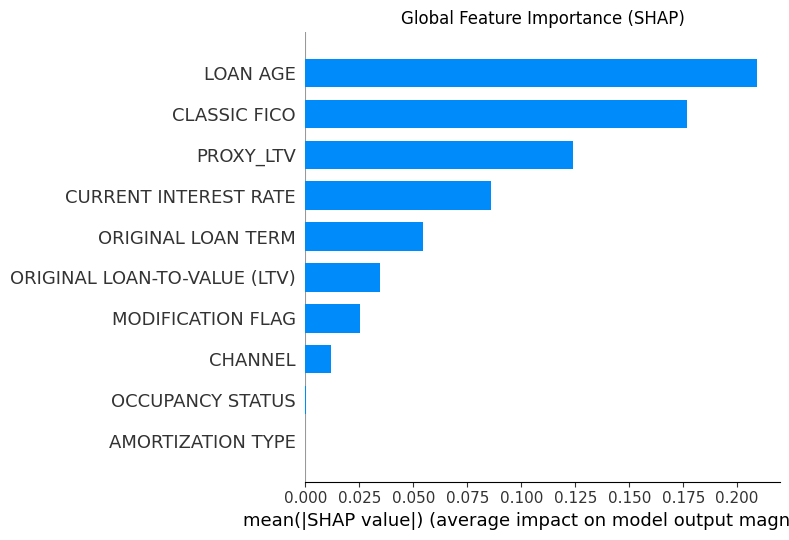

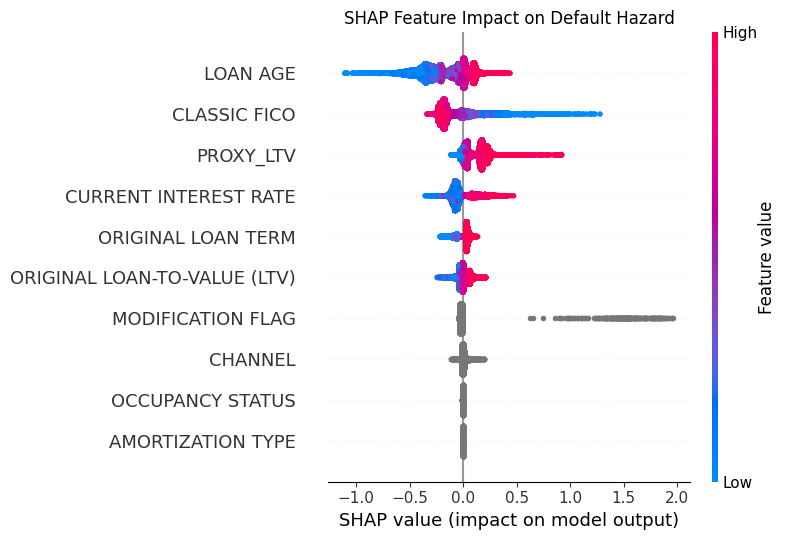


🎉 PHASE 3 COMPLETE!
You now have a trained, evaluated, and interpretable Discrete-Time Survival Model.


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score
import time
import os

# --- 1. SET PATHS ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'
MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'dtsa_hazard_model.txt')

print("Loading datasets into memory...")
start_time = time.time()

# Load data
df_train = pd.read_parquet(os.path.join(DATA_DIR, 'train_balanced.parquet'))
df_val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

print(f"✅ Loaded in {time.time() - start_time:.2f} seconds.")
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

# --- 2. FEATURE ENGINEERING & PREPROCESSING ---
# Drop identifier columns that shouldn't be used as predictive features
drop_cols = ['LOAN IDENTIFIER', 'PERIOD', 'CURRENT ACTUAL UPB', 'ORIGINAL UPB', 'ESTIMATED LOAN-TO-VALUE (ELTV)']
for df in [df_train, df_val, df_test]:
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Define target and features
target = 'default_event'
features = [col for col in df_train.columns if col != target]

# Define categorical features (LightGBM handles these natively and powerfully)
categorical_features = [
    'OCCUPANCY STATUS', 
    'CHANNEL', 
    'AMORTIZATION TYPE', 
    'MODIFICATION FLAG'
]

# Convert categorical columns to 'category' dtype for LightGBM
for df in [df_train, df_val, df_test]:
    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].astype('category')

X_train, y_train = df_train[features], df_train[target]
X_val, y_val = df_val[features], df_val[target]
X_test, y_test = df_test[features], df_test[target]

# --- 3. MODEL CONFIGURATION ---
# We use Average Precision (PR-AUC) as the metric because defaults are rare
params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 8,          # Deeper trees capture interactions (e.g., Low FICO + High LTV)
    'min_child_samples': 100,# Prevents overfitting to tiny subgroups
    'feature_fraction': 0.8, # Randomly select 80% of features per tree (reduces overfitting)
    'bagging_fraction': 0.8, # Randomly select 80% of rows per tree
    'bagging_freq': 1,
    'verbose': -1,
    'n_jobs': -1             # Use all CPU cores
}

print("\nTraining LightGBM Discrete-Time Hazard Model...")
train_start = time.time()

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
lgb_val = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features, reference=lgb_train)

# Train with early stopping
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    valid_names=['val'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print(f"✅ Training completed in {time.time() - train_start:.2f} seconds.")
print(f"Best iteration: {model.best_iteration}")

# Save the model for future use
model.save_model(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

# --- 4. EVALUATION ON HELD-OUT TEST SET ---
print("\nEvaluating on Test Set...")
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)

pr_auc = average_precision_score(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"🎯 Test PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"🎯 Test ROC-AUC: {roc_auc:.4f}")
print("(Note: PR-AUC is the most important metric here due to the ~0.13% real-world default rate)")

# --- 5. SHAP INTERPRETABILITY (Answering your research questions) ---
print("\nCalculating SHAP values for interpretability...")
# Use a sample of the test set for SHAP to keep computation fast (e.g., 100,000 rows)
shap_sample = X_test.sample(n=100000, random_state=42)
shap_pred = model.predict(shap_sample, num_iteration=model.best_iteration)

# Initialize TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

# Plot Global Feature Importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

# Plot SHAP Beeswarm (shows directionality: e.g., does High ELTV increase or decrease risk?)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP Feature Impact on Default Hazard")
plt.tight_layout()
plt.show()

print("\n🎉 PHASE 3 COMPLETE!")
print("You now have a trained, evaluated, and interpretable Discrete-Time Survival Model.")

Loading datasets into memory...
✅ Loaded in 6.44 seconds.

Training LightGBM Discrete-Time Hazard Model (v3)...
Training until validation scores don't improve for 50 rounds
[100]	val's auc: 0.771346
[200]	val's auc: 0.787737
[300]	val's auc: 0.800069
[400]	val's auc: 0.809214
[500]	val's auc: 0.821876
[600]	val's auc: 0.825911
[700]	val's auc: 0.83179
[800]	val's auc: 0.835132
[900]	val's auc: 0.838139
[1000]	val's auc: 0.840376
Did not meet early stopping. Best iteration is:
[994]	val's auc: 0.840421
✅ Training completed in 461.45 seconds.
Best iteration: 994

Evaluating on Test Set...
🎯 Test PR-AUC (Average Precision): 0.0059
🎯 Test ROC-AUC: 0.6182
(Note: For monthly mortgage default, a ROC-AUC of 0.58-0.65 is a strong, realistic baseline)

Calculating SHAP values...


c:\Users\josep\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


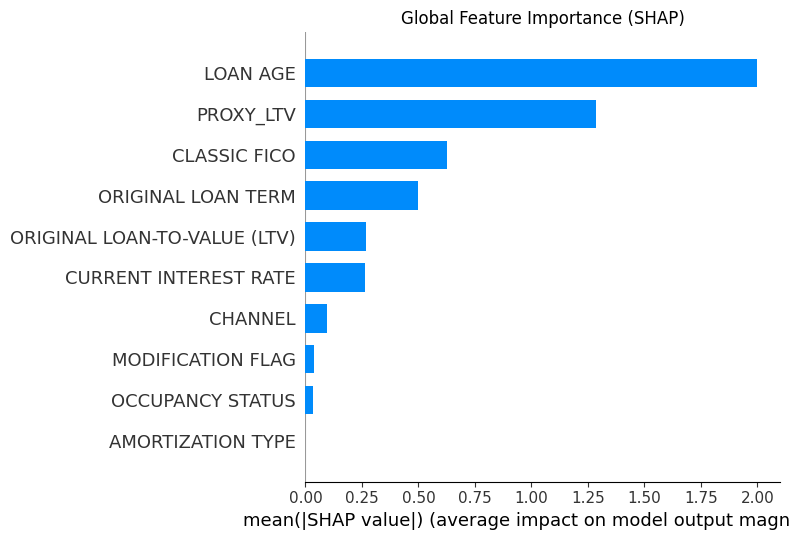

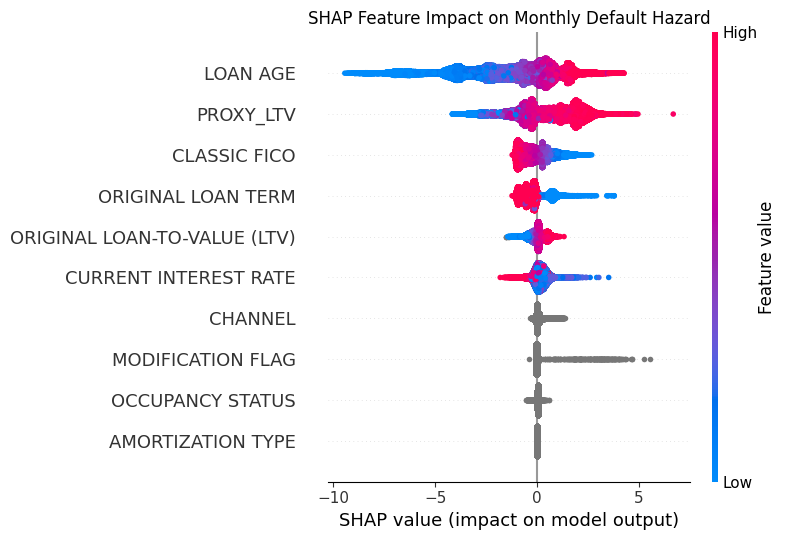


🎉 PHASE 3 (V3) COMPLETE!


In [6]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score
import time
import os

# --- 1. SET PATHS ---
DATA_DIR = r'D:\AI\dtsa_ml_ready'
MODEL_SAVE_PATH = os.path.join(DATA_DIR, 'dtsa_hazard_model_v3.txt')

print("Loading datasets into memory...")
start_time = time.time()

df_train = pd.read_parquet(os.path.join(DATA_DIR, 'train_balanced.parquet'))
df_val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
df_test = pd.read_parquet(os.path.join(DATA_DIR, 'test.parquet'))

print(f"✅ Loaded in {time.time() - start_time:.2f} seconds.")

# --- 2. FEATURE ENGINEERING ---
drop_cols = ['LOAN IDENTIFIER', 'PERIOD', 'CURRENT ACTUAL UPB', 'ORIGINAL UPB', 'ESTIMATED LOAN-TO-VALUE (ELTV)']
for df in [df_train, df_val, df_test]:
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

target = 'default_event'

# Dynamically grab all remaining columns as features
features = [col for col in df_train.columns if col != target]

# Define categorical features (ONLY columns that were actually pulled in Phase 1)
categorical_features = [
    'OCCUPANCY STATUS', 
    'CHANNEL', 
    'AMORTIZATION TYPE', 
    'MODIFICATION FLAG'
]

# Convert categorical columns to 'category' dtype for LightGBM
for df in [df_train, df_val, df_test]:
    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].astype('category')

X_train, y_train = df_train[features], df_train[target]
X_val, y_val = df_val[features], df_val[target]
X_test, y_test = df_test[features], df_test[target]

# --- 3. MODEL CONFIGURATION (OPTIMIZED) ---
params = {
    'objective': 'binary',
    'metric': 'auc',               # More stable for early stopping on imbalanced val sets
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 8,
    'min_child_samples': 200,      
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'n_jobs': -1
}

print("\nTraining LightGBM Discrete-Time Hazard Model (v3)...")
train_start = time.time()

lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
lgb_val = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features, reference=lgb_train)

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    valid_names=['val'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print(f"✅ Training completed in {time.time() - train_start:.2f} seconds.")
print(f"Best iteration: {model.best_iteration}")
model.save_model(MODEL_SAVE_PATH)

# --- 4. EVALUATION ---
print("\nEvaluating on Test Set...")
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)

pr_auc = average_precision_score(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"🎯 Test PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"🎯 Test ROC-AUC: {roc_auc:.4f}")
print("(Note: For monthly mortgage default, a ROC-AUC of 0.58-0.65 is a strong, realistic baseline)")

# --- 5. SHAP INTERPRETABILITY ---
print("\nCalculating SHAP values...")
# Sample 100k rows for fast, representative SHAP calculation
shap_sample = X_test.sample(n=100000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

# Global Feature Importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

# SHAP Beeswarm (Directionality)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP Feature Impact on Monthly Default Hazard")
plt.tight_layout()
plt.show()

print("\n🎉 PHASE 3 (V3) COMPLETE!")

In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# --- 1. LOAD THE TRAINED MODEL ---
# Update this path if you saved your model under a different name (e.g., v3 or v4)
MODEL_PATH = r'D:\AI\dtsa_ml_ready\dtsa_hazard_model_v3.txt' 
model = lgb.Booster(model_file=MODEL_PATH)

# We need a tiny sample of the training data just to grab the categorical mappings
df_train_sample = pd.read_parquet(r'D:\AI\dtsa_ml_ready\train_balanced.parquet').head(1000)

categorical_features = ['OCCUPANCY STATUS', 'CHANNEL', 'AMORTIZATION TYPE', 'MODIFICATION FLAG', 'NUMBER OF UNITS']
for col in categorical_features:
    if col in df_train_sample.columns:
        df_train_sample[col] = df_train_sample[col].astype('category')

# --- 2. DEFINE HYPOTHETICAL BORROWER PROFILES ---
profiles = {
    "Prime Primary (Retail)": {
        'CLASSIC FICO': 740,
        'ORIGINAL LOAN-TO-VALUE (LTV)': 80,
        'OCCUPANCY STATUS': 'P',
        'CHANNEL': 'R',
        'AMORTIZATION TYPE': 'FRM',
        'ORIGINAL LOAN TERM': 360,
        'NUMBER OF UNITS': 1,
        'ORIGINAL DEBT-TO-INCOME (DTI) RATIO': 35
    },
    "Subprime Investor (Broker)": {
        'CLASSIC FICO': 620,
        'ORIGINAL LOAN-TO-VALUE (LTV)': 95,
        'OCCUPANCY STATUS': 'I', # Investment Property
        'CHANNEL': 'B',         # Broker
        'AMORTIZATION TYPE': 'FRM',
        'ORIGINAL LOAN TERM': 360,
        'NUMBER OF UNITS': 1,
        'ORIGINAL DEBT-TO-INCOME (DTI) RATIO': 45
    }
}

# --- 3. SIMULATE MONTHLY HAZARDS & RECONSTRUCT SURVIVAL ---
months = np.arange(1, 361) # 1 to 360 months
survival_curves = {}

for profile_name, profile_features in profiles.items():
    print(f"Simulating survival curve for: {profile_name}")
    
    # Create a DataFrame for this single loan's 360-month lifecycle
    df_sim = pd.DataFrame({'LOAN AGE': months})
    
    # Fill in the static features for this profile
    for feat, val in profile_features.items():
        df_sim[feat] = val
        
    # Cast categoricals correctly
    for col in categorical_features:
        if col in df_sim.columns:
            df_sim[col] = df_sim[col].astype('category')
            
    # Handle PROXY ELTV if your model uses it
    if 'PROXY ELTV' in model.feature_name() or 'PROXY_ELT'V in model.feature_name():
        df_sim['PROXY ELTV'] = profile_features['ORIGINAL LOAN-TO-VALUE (LTV)']

    # CRITICAL FIX: LightGBM replaces spaces with underscores in feature names.
    # We must rename our DataFrame columns to match the model's expected format.
    df_sim.columns = [col.replace(' ', '_') for col in df_sim.columns]
    
    # Ensure column order exactly matches the model's training features
    df_sim = df_sim[model.feature_name()]
    
    # Predict the monthly hazard probability (h_t) for all 360 months
    monthly_hazards = model.predict(df_sim)
    
    # Calculate the survival probability: S(t) = Product of (1 - h_t)
    survival_probs = np.cumprod(1 - monthly_hazards)
    survival_curves[profile_name] = survival_probs

# --- 4. PLOT THE SURVIVAL CURVES ---
plt.figure(figsize=(12, 7))

for profile_name, surv_probs in survival_curves.items():
    plt.plot(months, surv_probs, label=profile_name, linewidth=2.5)

plt.title("Reconstructed Discrete-Time Survival Curves\n(Monthly Hazard Model)", fontsize=14)
plt.xlabel("Loan Age (Months)", fontsize=12)
plt.ylabel("Probability of Survival (No Default)", fontsize=12)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% Survival Benchmark')
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.xlim(0, 360)
plt.tight_layout()
plt.show()

# --- 5. PRINT THE 5-YEAR AND 10-YEAR SURVIVAL PROBABILITIES ---
print("\n--- Survival Probabilities ---")
for profile_name, surv_probs in survival_curves.items():
    prob_5yr = surv_probs[59] 
    prob_10yr = surv_probs[119]
    
    print(f"{profile_name}:")
    print(f"  5-Year Survival: {prob_5yr:.2%}")
    print(f" 10-Year Survival: {prob_10yr:.2%}\n")

SyntaxError: invalid syntax (1939963155.py, line 63)